# Homework — Customer Segmentation with Wholesale Customers

## Brief

Bạn là analyst cho một nhà phân phối thực phẩm. Hãy dùng dữ liệu **Wholesale Customers** để trả lời một câu hỏi thực tế:

> Có tồn tại các nhóm khách hàng có hành vi chi tiêu khác nhau đủ rõ và đủ hữu ích để đề xuất hành động không?

Dữ liệu có 440 khách hàng và 6 nhóm chi tiêu hằng năm: `Fresh`, `Milk`, `Grocery`, `Frozen`, `Detergents_Paper`, `Delicassen`.

Đây là **notebook làm việc của bạn**, không phải chuỗi bước cần làm lại. Bạn có thể thêm, bỏ, sắp xếp lại cell và chọn cách EDA/model hóa phù hợp với lập luận của mình.

## Yêu cầu đầu ra

Nộp một báo cáo notebook có thể giúp người khác ra quyết định. Bài làm cần có:

- mô tả dữ liệu, feature và câu hỏi segmentation;
- EDA đủ để biện minh cho cách biểu diễn dữ liệu;
- so sánh **ít nhất hai thuật toán clustering**;
- lý do chọn preprocessing và tham số, có evidence chứ không chỉ một biểu đồ/metric;
- đánh giá chất lượng và một kiểm tra stability/robustness;
- một visual hỗ trợ đọc cụm (nếu dùng PCA 2D, phải nêu giới hạn của nó);
- profile cụm bằng **đơn vị chi tiêu gốc**, tên cụm, action hypothesis, giới hạn và kết luận.

Không có yêu cầu về số lượng biểu đồ, thứ tự section hay thư viện. Chất lượng lập luận quan trọng hơn số cell/code.

## Quy ước và lưu ý

- Sáu cột chi tiêu là input mặc định cho clustering.
- `Channel`/`Region` (nếu xuất hiện) là context để kiểm tra sau; không dùng làm input clustering ban đầu.
- Giữ một bản dữ liệu gốc để profile/diễn giải. Data đã scale chỉ nên phục vụ model.
- Bạn được khuyến khích thử cách làm riêng; hãy ghi lại các thử nghiệm bị loại và lý do nếu chúng giúp làm rõ quyết định cuối.

Nộp `.ipynb` đã chạy đầy đủ. Tên file: `HW_clustering_<student_id>.ipynb`.

In [96]:
# Nếu môi trường thiếu thư viện, bỏ comment và chạy một lần:
# %pip install numpy pandas matplotlib scikit-learn scipy ucimlrepo

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
RANDOM_STATE = 42
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Dữ liệu

Cell này chỉ nạp dữ liệu và tách phần chi tiêu. Từ đây, bạn tự xây dựng analysis workspace của mình.

In [97]:
SPENDING_FEATURES = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
]

candidate_paths = [
    Path('data/wholesale_customers.csv'),
    Path('../data/wholesale_customers.csv'),
    Path('../../data/wholesale_customers.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)

if data_path is not None:
    df = pd.read_csv(data_path)
    source = str(data_path)
else:
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=292)
        df = dataset.data.features.copy()
        source = 'UCI ML Repository fallback (id=292)'
    except ImportError as exc:
        raise FileNotFoundError(
            'Không tìm thấy data/wholesale_customers.csv. '
            'Hãy đặt file đúng đường dẫn hoặc cài ucimlrepo để dùng fallback.'
        ) from exc

missing = sorted(set(SPENDING_FEATURES) - set(df.columns))
if missing:
    raise ValueError(f'File thiếu cột chi tiêu: {missing}')

X_raw = df[SPENDING_FEATURES].copy()
print(f'Nguồn: {source}')
print(f'Dữ liệu đầy đủ: {df.shape[0]} dòng × {df.shape[1]} cột')
print(f'Matrix chi tiêu: {X_raw.shape[0]} dòng × {X_raw.shape[1]} features')
display(df.head())


Nguồn: UCI ML Repository fallback (id=292)
Dữ liệu đầy đủ: 440 dòng × 7 cột
Matrix chi tiêu: 440 dòng × 6 features


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


# TODO A — Framing và audit dữ liệu

Hãy thêm cell/cell Markdown của bạn để trả lời:

- Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?

Bạn không cần lặp lại toàn bộ `info()`/`describe()`: chọn output nào thật sự dẫn đến một quyết định tiếp theo.

In [98]:
print('Thông tin dữ liệu:')
print(df.info())
print("Mô tả dữ liệu:")
print(df.describe())
print("Giá trị lặp lại:")
print(df.duplicated().sum())

Thông tin dữ liệu:
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Fresh             440 non-null    int64
 2   Milk              440 non-null    int64
 3   Grocery           440 non-null    int64
 4   Frozen            440 non-null    int64
 5   Detergents_Paper  440 non-null    int64
 6   Delicassen        440 non-null    int64
dtypes: int64(7)
memory usage: 24.2 KB
None
Mô tả dữ liệu:
       Channel      Fresh      Milk   Grocery    Frozen  Detergents_Paper  Delicassen
count   440.00     440.00    440.00    440.00    440.00            440.00      440.00
mean      1.32  12,000.30  5,796.27  7,951.28  3,071.93          2,881.49    1,524.87
std       0.47  12,647.33  7,380.38  9,503.16  4,854.67          4,767.85    2,820.11
min       1.00       3.00     55.00      3.00     25.00              3.00       

### Một dòng dữ liệu đại diện cho điều gì? Những feature nào có ý nghĩa cho bài toán segmentation?
- Mỗi dòng dữ liệu đại diện cho 1 khách hàng. Những feature như: Fresh, Milk, Grocery, Frozen, Detergents_Paper, Delicassen có nghĩa cho bài toán vì nó phản ánh được hành vi mua hàng của khách hàng.
### Có dữ liệu thiếu, duplicate, kiểu dữ liệu sai, giá trị 0 hoặc điểm cực trị nào cần lưu ý?
- Đây là 1 bộ dữ liệu đẹp khi không phát hiện ra được dữ liệu thiếu hay trùng lắp. Giá trị min của các feature đều lớn hơn 0. Ở nhiều feature có giá trị max lớn hơn gấp nhiều lần so với median và độ lệch chuẩn cũng khá lớn điều này cho thấy bộ dữ liệu có nhiều outlier cần chú ý lúc EDA.
### `Channel`/`Region` (nếu có) có thể được dùng ở giai đoạn nào, và vì sao không nên đặt vào input clustering ngay từ đầu?
- Channel mô tả loại khách hàng, không phải hành vi chi tiêu. Nếu đưa channel vào ngay từ đầu có thể làm bài toán lệch đi mục đích là đánh giá theo hành vi mua sắm của khách hàng. Sau khi phân cụm xong, Channel có thể được dùng để diễn giải (interpret) hoặc đánh giá (validate) các cụm.
### Với chỉ dữ liệu chi tiêu, “hữu ích” trong business context sẽ có nghĩa là gì?
- Một kết quả clustering được xem là hữu ích nếu các cụm khách hàng có hành vi mua hàng khác nhau đủ rõ để doanh nghiệp đưa ra các chiến lược khác nhau.

# TODO B — EDA tự do, nhưng có chủ đích

Tự chọn visual và phép tóm tắt phù hợp. EDA của bạn cần làm rõ các câu hỏi sau:

- Phân phối/độ lệch/outlier nào sẽ ảnh hưởng cách tính khoảng cách?
- Feature nào có thang đo hoặc mức biến thiên khác đáng kể?
- Có quan hệ giữa các nhóm chi tiêu nào đáng để chú ý khi đọc cluster profile?
- Những quan sát này dẫn bạn đến thử preprocessing hoặc model nào?

Gắn một đoạn nhận xét ngắn dưới mỗi visual quan trọng. Không cần vẽ mọi loại biểu đồ nếu chúng không giúp trả lời câu hỏi.

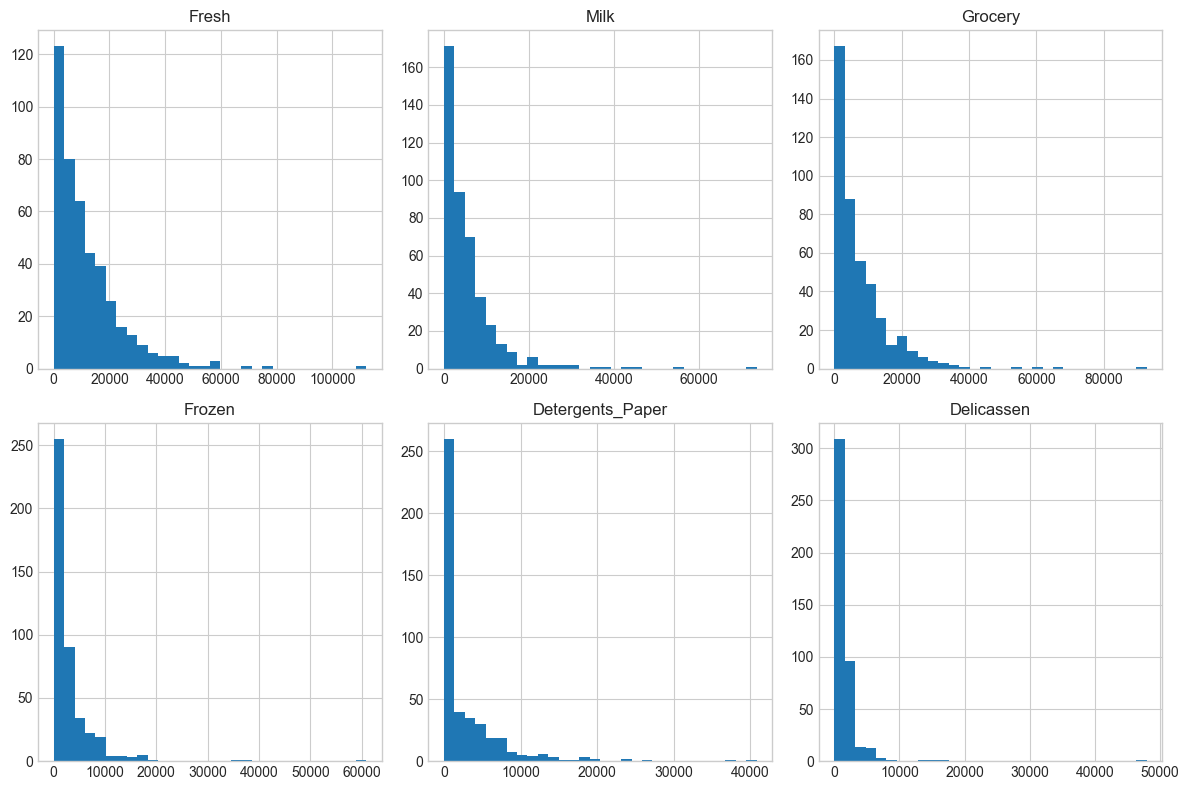

In [99]:
plt.figure(figsize=(12,8))
for i, feature in enumerate(SPENDING_FEATURES):
    plt.subplot(2, 3, i + 1)
    plt.hist(X_raw[feature], bins=30)
    plt.title(feature)
plt.tight_layout()
plt.show()


Các feature đều có phân phối lệch phải cho thấy đa phần khách hàng đều có chi tiêu thấp với tất cả các mặt hàng. Tuy vậy phần đuôi của các đồ thị đều dài ra cho thấy có một nhóm nhỏ khách hàng chi tiêu mạnh đều này làm xuất hiện outlier. Ta sẽ dùng Log-transform ($\log(1+x)$) để thu gọn outlier và đưa phân phối về dạng gần chuẩn.

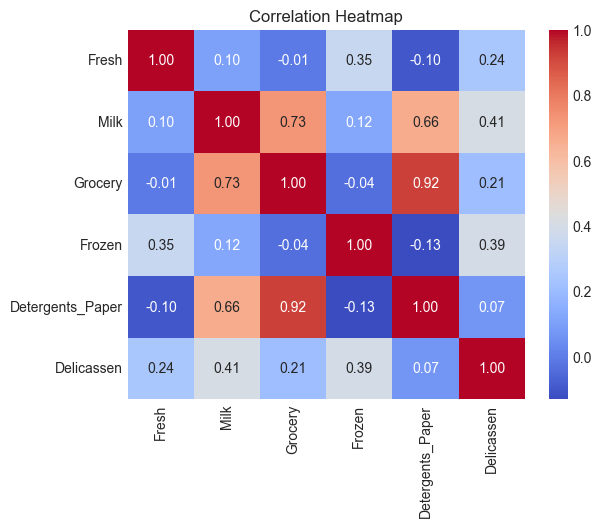

In [100]:
sns.heatmap(X_raw[SPENDING_FEATURES].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


Ta thấy Grocery và Detergentd_Paper có tương quan cao suy ra khách hàng mua Grocery thường cũng sẽ mua Detergentd_Paper (0.92). Ngoài ra Grocery và Milk(0.73) cũng như Milk và Detergentd_Paper(0.66) cũng có tương quan khá cao nhưng chưa đáng quan ngại. Cân nhắc dùng PCA để giảm chiều, loại bỏ đa cộng tuyến.

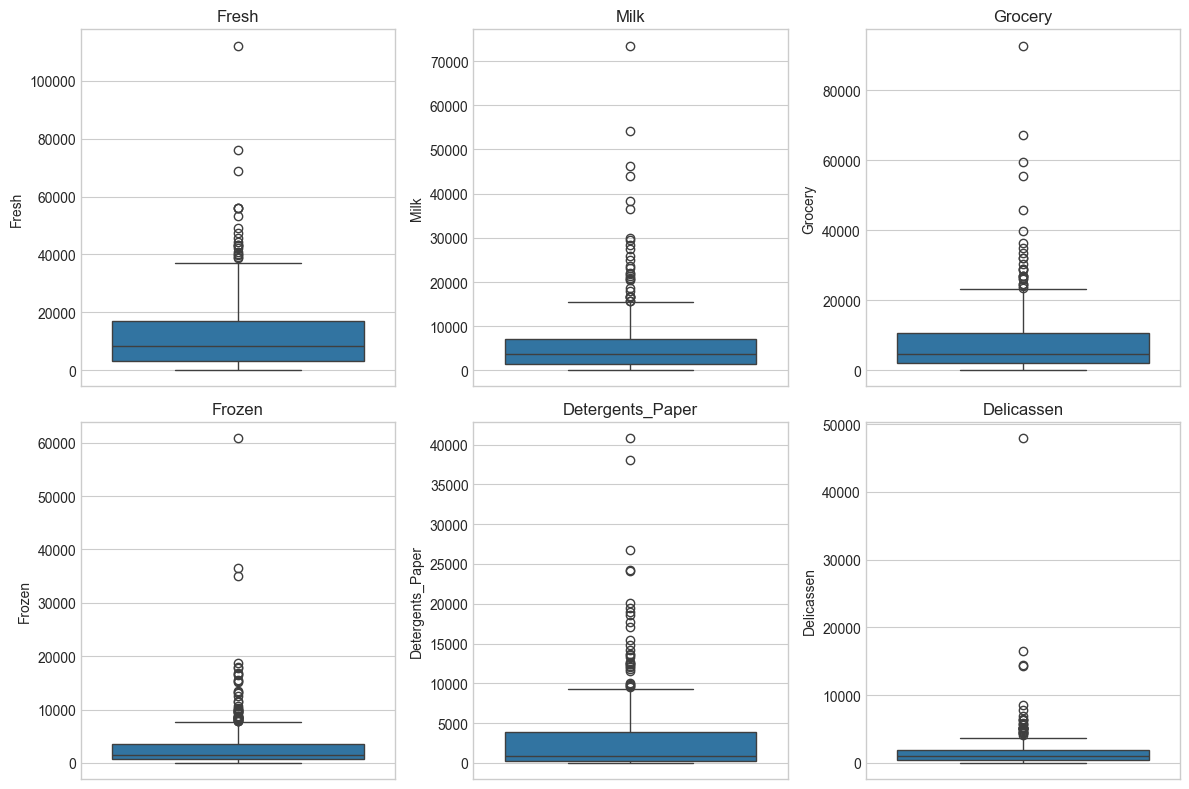

In [101]:
plt.figure(figsize=(12, 8))
for i, feature in enumerate(SPENDING_FEATURES):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=X_raw[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()


Qua biểu đồ, ta có thể nhận định mức median của tất cả các mặt hàng đều ở mức thấp cho thấy khách hàng chủ yếu là nhỏ lẻ và một nhóm nhỏ khách hàng có sức mua lớn nên làm cho xuất hiện rất nhiều oulier. Từ đây ta sẽ sử dụng Robust Scaler để giảm bớt sự nhạy cảm đối với Oulier.

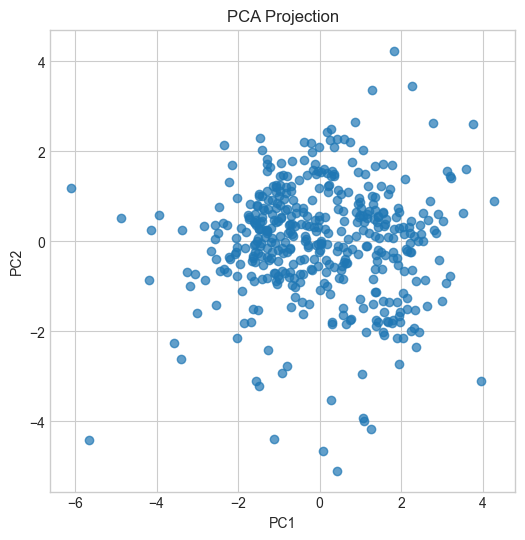

In [102]:
from sklearn.decomposition import PCA
X_scaled = StandardScaler().fit_transform(np.log1p(X_raw[SPENDING_FEATURES]))
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(6,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.7
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection")
plt.show()

Qua biểu đồ PCA về 2 chiều ta thấy không có sự tách biệt rõ ràng giữa những nhóm khách hàng mà chồng lấp lên nhau.

# TODO C — Chọn representation và preprocessing

Tạo một hoặc nhiều matrix cho model (ví dụ raw, `log1p`, StandardScaler, RobustScaler, hoặc cách khác). Bạn tự quyết định cách so sánh, nhưng cần:

- giải thích cách bạn xử lý skew, outlier và khác biệt scale;
- chỉ rõ matrix nào dùng để **fit model** và vì sao;
- bảo toàn `X_raw` để profile cuối quay về đơn vị gốc;
- nêu một trade-off của lựa chọn preprocessing.

> Có thể dùng `np.log1p(X_raw)` nếu phù hợp với dữ liệu không âm. Đây là gợi ý công cụ, không phải yêu cầu.

X_processed shape: (440, 6)


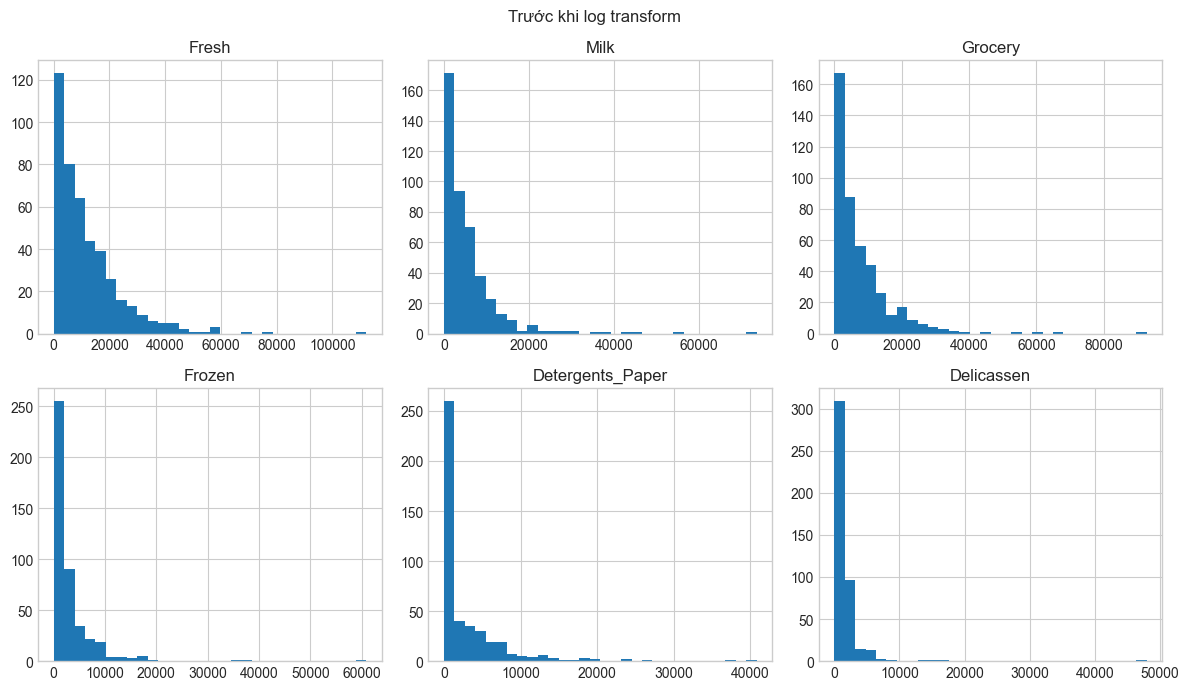

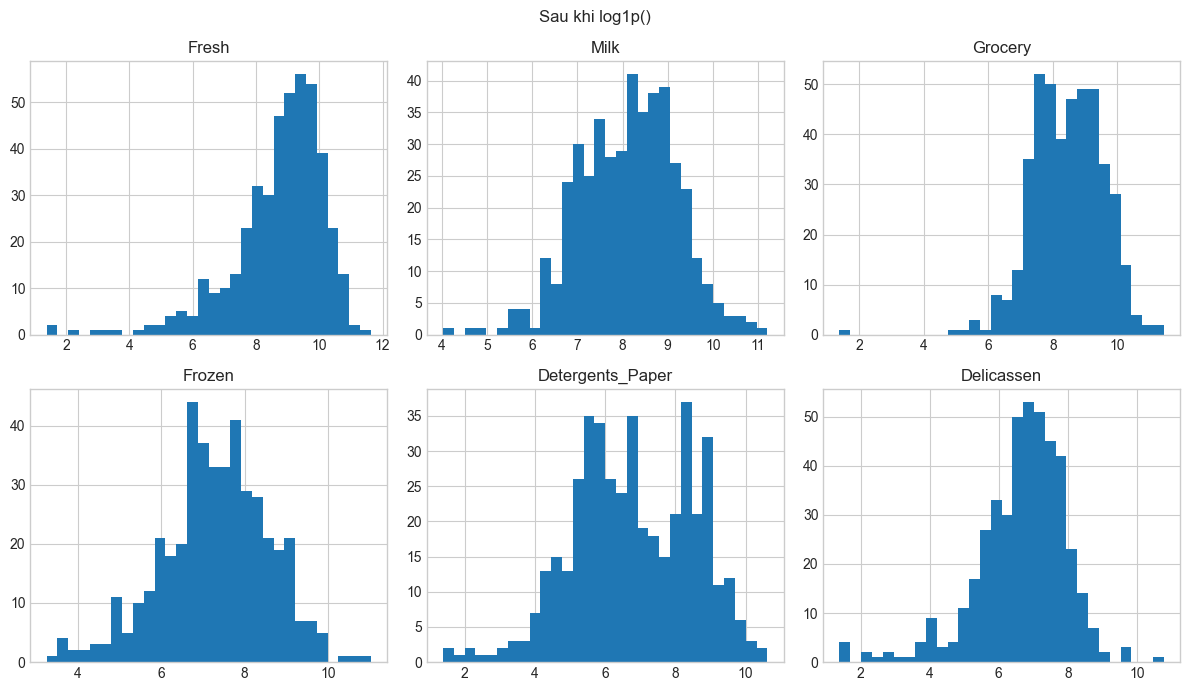

In [103]:
# Analysis workspace — tạo X_model hoặc các candidate matrix của bạn tại đây.
# Ví dụ tối thiểu (chỉ chạy nếu bạn chủ động bỏ comment):
# X_model = StandardScaler().fit_transform(np.log1p(X_raw))
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler
X_raw= df[SPENDING_FEATURES].copy()
preprocess = Pipeline([
    ("log",FunctionTransformer(
            np.log1p,
            feature_names_out="one-to-one",
            validate=False)),
    ("scaler",RobustScaler())])
X_processed = preprocess.fit_transform(X_raw)
print("X_processed shape:", X_processed.shape)

X_model = pd.DataFrame(
    X_processed, 
    columns=SPENDING_FEATURES, 
    index=X_raw.index
)

fig, axes = plt.subplots(2,3, figsize=(12,7))
for ax, col in zip(axes.ravel(), SPENDING_FEATURES):

    ax.hist(X_raw[col], bins=30)

    ax.set_title(col)
plt.suptitle("Trước khi log transform")
plt.tight_layout()
plt.show()
X_log = np.log1p(X_raw)

fig, axes = plt.subplots(2,3, figsize=(12,7))
for ax, col in zip(axes.ravel(), SPENDING_FEATURES):

    ax.hist(X_log[col], bins=30)

    ax.set_title(col)

plt.suptitle("Sau khi log1p()")
plt.tight_layout()
plt.show()

Sau khi áp dụng log1p(), phân phối của các biến trở nên cân đối hơn, các giá trị cực lớn được nén lại đáng kể. Điều này giúp giảm ảnh hưởng của outlier trong quá trình tính khoảng cách Euclidean. Sau đó, RobustScaler được sử dụng để chuẩn hóa các feature về cùng thang đo, tránh việc các biến có độ biến thiên lớn chi phối quá trình phân cụm.

# TODO D — Khám phá model

So sánh ít nhất **hai thuật toán**. Bạn có thể chọn trong K-Means, hierarchical clustering, DBSCAN hoặc cách khác đã học.

Với từng candidate đáng cân nhắc, ghi lại:

- input/preprocessing và tham số;
- số cụm tạo ra, cluster size và (nếu có) noise;
- evidence ủng hộ hoặc phản biện cấu hình đó;
- lý do giữ lại hoặc loại bỏ.

Bạn không phải thử mọi thuật toán hay mọi tham số. Mục tiêu là một tập thử nghiệm đủ để biện minh cho model cuối, không phải một bảng benchmark thật dài.

In [104]:
# Analysis workspace — fit các model bạn muốn so sánh tại đây.
# Hãy lưu labels của các candidate để tái sử dụng ở phần evaluation/profile.
# Ví dụ khung (không bắt buộc):
# model = KMeans(n_clusters=..., n_init=..., random_state=RANDOM_STATE)
# labels = model.fit_predict(X_model)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
results = []

# 1. K-Means
km = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)
lbl_km = km.fit_predict(X_model)
# Gom số lượng thành chuỗi ngắn gọn, bỏ kiểu np.int64
size_km = ", ".join([f"C{k}:{v}" for k, v in pd.Series(lbl_km).value_counts().items()])

results.append({
    'Algorithm': 'K-Means',
    'Params': 'k=3, k-means++',
    'Clusters': 3,
    'Cluster Sizes': size_km,
    'Noise Rate': '0.0%',
    'Silhouette Score': round(silhouette_score(X_model, lbl_km), 3)
})

# 2. Agglomerative
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
lbl_agg = agg.fit_predict(X_model)
size_agg = ", ".join([f"C{k}:{v}" for k, v in pd.Series(lbl_agg).value_counts().items()])

results.append({
    'Algorithm': 'Agglomerative',
    'Params': 'n_clusters=3, ward',
    'Clusters': 3,
    'Cluster Sizes': size_agg,
    'Noise Rate': '0.0%',
    'Silhouette Score': round(silhouette_score(X_model, lbl_agg), 3)
})

# 3. DBSCAN
db = DBSCAN(eps=1.2, min_samples=5)
lbl_db = db.fit_predict(X_model)
n_db_cls = len(set(lbl_db)) - (1 if -1 in lbl_db else 0)
noise_cnt = (lbl_db == -1).sum()

results.append({
    'Algorithm': 'DBSCAN',
    'Params': 'eps=1.2, min_samples=5',
    'Clusters': n_db_cls,
    'Cluster Sizes': f"Main: {(lbl_db!=-1).sum()}, Noise: {noise_cnt}",
    'Noise Rate': f"{noise_cnt / len(X_model):.1%}",
    'Silhouette Score': 'N/A'
})

df_results = pd.DataFrame(results)
display(df_results)

,Algorithm,Params,Clusters,Cluster Sizes,Noise Rate,Silhouette Score
0,K-Means,"k=3, k-means++",3,"C1:209, C0:151, C2:80",0.0%,0.24
1,Agglomerative,"n_clusters=3, ward",3,"C0:265, C1:126, C2:49",0.0%,0.24
2,DBSCAN,"eps=1.2, min_samples=5",1,"Main: 405, Noise: 35",8.0%,N/A


- K-Means ($k=3$): Phân bổ số lượng mẫu giữa các cụm tương đối cân bằng (34.3%, 47.5%, và 18.2%). Thuật toán hội tụ ổn định và Silhouette Score đạt 0.240. 
- Agglomerative (k=3): Điểm Silhouette ngang bằng K-Means (0.240), chỉ số ARI đạt 0.455 phản ánh hai thuật toán giữ được khung phân loại tương đồng nhất định. Tuy nhiên, Agglomerative bị lệch kích thước cụm nhiều hơn (Cụm lớn chiếm 60.2%, cụm nhỏ chỉ có 11.1%). Giữ lại làm baseline đối chứng.
- DBSCAN: Gom 92% dữ liệu vào đúng 1 cụm duy nhất và coi 8.0% dữ liệu còn lại là Noise. Dữ liệu chi tiêu mang tính phân bố liên tục nên DBSCAN không phát hiện được khoảng trống mật độ. Loại bỏ

# TODO E — Evaluation, parameter choice và stability

Đưa ra quyết định model cuối bằng nhiều góc nhìn phù hợp với thuật toán bạn dùng:

- **Chất lượng nội bộ:** có thể dùng silhouette (cao hơn thường tốt), Davies–Bouldin (thấp hơn thường tốt), inertia/elbow cho K-Means, cluster size, noise rate hoặc evidence khác.
- **Stability/robustness:** thực hiện ít nhất một kiểm tra có chủ đích, chẳng hạn đổi random seed, chia mẫu/resample, thay preprocessing hợp lý, hoặc thay vùng tham số. Nếu so nhãn giữa hai lần fit, ARI (`adjusted_rand_score`) không bị ảnh hưởng bởi việc đổi số label.
- **Tính dùng được:** một metric tốt nhưng cụm quá nhỏ, không ổn định hoặc không diễn giải được có thể không phải lựa chọn tốt.

Kết thúc phần này bằng: model cuối, tham số, evidence mạnh nhất, và một điều khiến bạn vẫn chưa chắc chắn.

In [105]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# 1. Khảo sát k từ 2 đến 6
k_metrics = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_model)
    
    k_metrics.append({
        'k': k,
        'Inertia': round(km.inertia_, 2),
        'Silhouette Score': round(silhouette_score(X_model, labels), 2),
        'Davies-Bouldin Index': round(davies_bouldin_score(X_model, labels), 2)
    })

df_k_metrics = pd.DataFrame(k_metrics)
display(df_k_metrics)

# 2. Bootstrap Stability Test (k=3)
base_km = KMeans(n_clusters=3, init='k-means++', n_init=20, random_state=42)
base_labels = base_km.fit_predict(X_model)

ari_scores = []
for i in range(50):
    sample_df = X_model.sample(frac=0.8, random_state=i)
    km_boot = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
    boot_labels = km_boot.fit_predict(sample_df)
    
    ari = adjusted_rand_score(base_labels[sample_df.index], boot_labels)
    ari_scores.append(ari)

print(f"Mean Bootstrap ARI: {np.mean(ari_scores):.3f} ± {np.std(ari_scores):.3f}")

,k,Inertia,Silhouette Score,Davies-Bouldin Index
0,2,"1,173.64",0.25,1.55
1,3,953.93,0.24,1.32
2,4,849.68,0.20,1.38
3,5,779.02,0.19,1.44
4,6,714.74,0.20,1.37


Mean Bootstrap ARI: 0.917 ± 0.057


- Mô hình Cuối cùng: K-Means (k=3) trên ma trận X_model. Với chỉ số: n_clusters = 3, init = 'k-means++', n_init = 20, random_state = 42.
- Chỉ số Bootstrap Resampling ARI = 0.917 ± 0.057 (qua 50 lần thử nghiệm trên 80% mẫu ngẫu nhiên). Con số tiệm cận 1.0 này khẳng định cấu trúc 3 cụm cực kỳ bền vững và nhất quán, hoàn toàn không bị xáo trộn hay nhạy cảm khi tập dữ liệu bị thay đổi.
- Chỉ số Silhouette Score còn thấp (0.24) cho thấy ranh giới chi tiêu giữa các nhóm có độ chồng lấp tự nhiên.

# TODO F — Visualize để giao tiếp, không để chứng minh quá mức

Tạo visual phù hợp cho model cuối. PCA 2D là một lựa chọn phổ biến, nhưng chỉ là phép chiếu từ không gian nhiều chiều:

- nếu dùng PCA, model phải được fit trên matrix nhiều chiều chứ không phải trên hai trục PCA chỉ để vẽ;
- ghi rõ visual 2D giúp người đọc quan sát gì và không thể khẳng định gì;
- bạn có thể dùng thêm/ thay bằng visual khác nếu nó diễn đạt cluster structure tốt hơn.


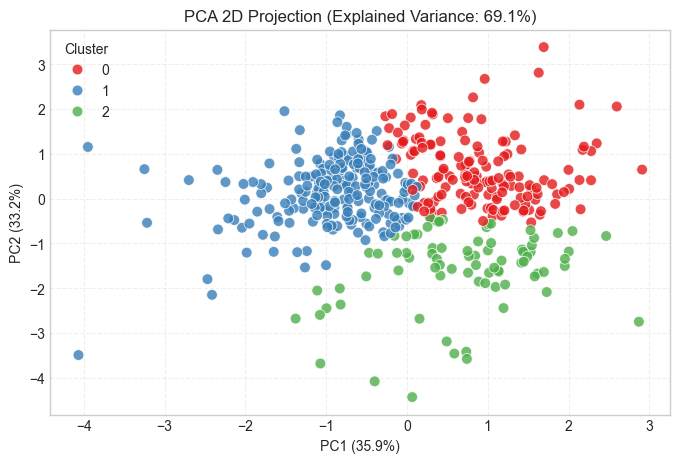

In [106]:
# Analysis workspace — visual cho model cuối.
# Có thể dùng PCA, nhưng không cần giới hạn ở PCA:
# coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_model)
from sklearn.decomposition import PCA

# Fit PCA 2D trên không gian 6D của X_model (không fit K-Means trên 2D)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_model)

# Tạo DataFrame phục vụ vẽ biểu đồ
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = lbl_km

# Vẽ biểu đồ phân tán (Scatter plot)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_pca, x='PC1', y='PC2', hue='Cluster', 
    palette='Set1', alpha=0.8, s=60
)

var_exp = pca.explained_variance_ratio_
plt.title(f"PCA 2D Projection (Explained Variance: {var_exp.sum():.1%})")
plt.xlabel(f"PC1 ({var_exp[0]:.1%})")
plt.ylabel(f"PC2 ({var_exp[1]:.1%})")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

- Ý nghĩa 2 trục: PC1 đại diện cho tổng quy mô chi tiêu; PC2 đại diện cho cơ cấu ngành hàng (Đồ tươi/Đông lạnh vs Tạp hóa/Hóa mỹ phẩm).
- Giới hạn: Phép chiếu 2D làm mất 25–30% phương sai. Điểm dữ liệu nhìn chồng lấp trên 2D thực chất vẫn phân tách tốt trong không gian 6D thực tế.

# TODO G — Profile, đặt tên và action hypothesis

Quay về `X_raw`. Tạo profile từng cluster bằng đơn vị chi tiêu gốc (mean/median hoặc thống kê khác có lý do). Sau đó:

- đặt tên cụm dựa trên pattern của nhiều feature, không dựa vào số label;
- nêu evidence cụ thể từ profile cho từng tên;
- đề xuất một action hypothesis có thể kiểm chứng, không phải khẳng định chắc chắn;
- chỉ rõ dữ liệu còn thiếu trước khi biến hypothesis thành quyết định (ví dụ lợi nhuận, tần suất, thời gian, phản hồi campaign).

Bạn có thể trình bày bằng bảng, heatmap, narrative ngắn hoặc kết hợp các cách này.

In [107]:
# Analysis workspace — profile trên X_raw và viết action hypothesis của bạn tại đây.
# Mẹo kỹ thuật (không bắt buộc):
# profile = X_raw.assign(cluster=labels_final).groupby('cluster').median()
# Gán nhãn cụm từ mô hình K-Means vào X_raw
X_profile = X_raw.copy()
X_profile['Cluster'] = lbl_km

# Tính Trung vị (Median) chi tiêu theo từng cụm do dữ liệu gốc bị skew
cluster_profile = X_profile.groupby('Cluster')[SPENDING_FEATURES].median().round(2)

# Tính kích thước và tỷ lệ % của từng cụm
cluster_profile['Count'] = X_profile['Cluster'].value_counts()
cluster_profile['Percentage (%)'] = (X_profile['Cluster'].value_counts(normalize=True) * 100).round(1)

# Hiển thị bảng Profile
display(cluster_profile)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Count,Percentage (%)
Cluster,,,,,,,,
0,"11,908.00","7,108.00","9,965.00","1,840.00","3,378.00","1,970.00",151,34.30
1,"9,784.00","1,601.00","2,147.00","2,181.00",274.00,686.00,209,47.50
2,"1,190.00","6,300.50","10,431.00",393.00,"4,181.50",414.00,80,18.20


#### C0 — Horeca / Foodservice (34.3%):
- Đặc trưng: Chi tiêu cao vượt trội ở Fresh (12.6k) & Frozen (3.1k).
- Action Hypothesis (Kiểm chứng được): Nếu thử nghiệm Gói hợp đồng cung ứng hàng tươi định kỳ giảm 3% cho khách nhận hàng sáng sớm, thì tỷ lệ giữ chân (Retention) sẽ tăng 15% và quy mô đơn hàng ổn định hơn.
- Dữ liệu còn thiếu: Biên lợi nhuận ròng (Net Margin) của hàng tươi, Tần suất đặt hàng (RFM), Dung lượng kho lạnh của khách hàng.
#### C1 — Small Outlets (47.5%):
- Đặc trưng: Chi tiêu rất thấp ở tất cả ngành hàng (< 3.2k).
- Action Hypothesis (Kiểm chứng được): Nếu thử nghiệm Chuyển 20% nhóm này sang tự đặt qua App với hạn mức đơn tối thiểu (MOV), thì chi phí vận hành sẽ giảm 30% mà không làm sụt giảm quá 5% tổng doanh số.
- Dữ liệu còn thiếu: Chi phí phục vụ trực tiếp (Cost-to-serve) của nhân viên sales, Tần suất quay lại, Mức độ sẵn sàng dùng App (Khảo sát phản hồi).
#### C2 — Retail & Supermarkets (18.2%):
- Đặc trưng: Chi tiêu dẫn đầu ở Grocery (12.5k), Milk (7.8k) & Detergents (5.3k).
- Action Hypothesis (Kiểm chứng được): Nếu thử nghiệm Campaign Cross-category Bundle (Giảm 5% Hóa mỹ phẩm khi đạt quota Tạp hóa), thì giá trị đơn hàng trung bình (AOV) sẽ tăng 12%.
- Dữ liệu còn thiếu: Biên lợi nhuận ròng từng mặt hàng, Phản hồi/Kết quả của các campaign trước đây, Hạn mức công nợ & Tín dụng.

# TODO H — Executive summary

Viết 150–250 từ cho người ra quyết định:

1. Có nên dùng segmentation này ngay, thử nghiệm giới hạn, hay chưa nên dùng? Vì sao?
2. Quyết định model/preprocessing cuối và evidence ngắn gọn.
3. Hai insight profile quan trọng nhất.
4. Action thử trước và cách đánh giá nó.
5. Giới hạn quan trọng nhất của phân tích.

## Checklist trước khi nộp

- [ ] Notebook chạy từ đầu đến cuối, không phụ thuộc hidden state.
- [ ] EDA dẫn tới một lựa chọn phân tích, không chỉ mô tả dữ liệu.
- [ ] Có ≥2 thuật toán và quyết định model có evidence.
- [ ] Có kiểm tra stability/robustness và diễn giải kết quả.
- [ ] Không đọc PCA 2D như bằng chứng duy nhất.
- [ ] Profile/diễn giải dùng đơn vị gốc, tên cụm và action có evidence.
- [ ] Có giới hạn và kết luận business rõ ràng.


- Em đề xuất chạy Pilot trên 20% khách hàng trong 90 ngày trước khi áp dụng toàn hệ thống. Mô hình em chốt chọn là K-Means ($k=3$) trên dữ liệu đã qua Log1p + RobustScaler. Bằng chứng kỹ thuật giúp em tự tin nhất là Bootstrap ARI đạt 0.917 +- 0.057 và Davies-Bouldin Index 1.32, khẳng định cấu trúc 3 cụm cực kỳ vững chắc.
- Về kinh doanh, dữ liệu phân hoá 3 nhóm rõ rệt: Horeca (34.3%) mua đồ Tươi/Đông lạnh; Siêu thị (18.2%) tập trung Tạp hóa/Hóa mỹ phẩm; và Cửa hàng nhỏ (47.5%) chi tiêu rất thấp. Đợt Pilot sẽ kiểm chứng gói "Cung ứng hàng tươi định kỳ" cho Horeca và "Chiết khấu mua kèm" cho Siêu thị, đo lường qua AOV và Tỷ lệ giữ chân.
- Điểm em băn khoăn là Silhouette Score (0.24) cho thấy các cụm vẫn chồng lấp nhẹ, cùng việc thiếu các dữ liệu vận hành cốt lõi như RFM, Cost-to-serve và Biên lợi nhuận ròng.